<a href="https://colab.research.google.com/github/daniel-usp/USP/blob/main/Sensibilidade_pol_mon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimando a sensibilidade da política monetária sobre a atividade econômica no Brasil

A política monetária tem um papel importante na economia moderna, dispondo de diferentes instrumentos para alcançar a estabilidade estabilidade econômica, mantendo o controle sobre a inflação. A principal autoridade monetária do país utiliza desses artificios, proporcionando mudanças através dos “canais de transmissão”, que são meios pelos quais a taxa básica de juros — a Selic — afeta outras variáveis macroeconômicas relevantes. Mas como saber o efeito dessa transmissão para a atividade econômica?

Os instrumentos disposto pela política monetária objetivam alcançar com metas finais o controle da inflação, a estabilidade do nível de atividade econômica, o gerenciamento da taxa de desemprego, bem como outras metas.

Isso é realizado através dos canais de transmissão, que são afetados por tais instrumentos, e consequentemente em segunda instância por mudanças na taxa básica de juros, a Selic. Entre os principais canais, temos: Consumo e investimento, Canal do Crédito, Expectativas, entre outros.

Mas como saber o efeito da tais mudanças da taxa de básica de juros sobre a atividade econômica? Na macroeconomia moderna é utilizada a chamada “curva IS” realizar essa comparação. Mais especificamente, a curva IS é uma equação que representa o lado da demanda agregada da economia e relaciona uma estimativa do hiato do produto com a taxa de juros real e outras variáveis.

O hiato do produto representa o componente cíclico da atividade econômica, ou seja, reflete condições conjunturais da economia, como choques de demanda/oferta, incentivos de política econômica, condições climáticas, choques externos, incertezas políticas, etc.

Sendo assim, para avaliar a transmissão da política monetária do canal da taxa de juros para a atividade econômica é necessário estimar uma curva IS. Neste exercício o objetivo é verificar se a relação esperada na teoria econômica (-) é encontrada com os dados brasileiros, além de verificar a evolução e a magnitude dessa relação ao longo do tempo.

Para tanto, estimamos uma Curva IS, baseando-se no Modelo Semiestrutural de pequeno porte do BCB ([RI2021T2](https://www.bcb.gov.br/content/ri/relatorioinflacao/202103/ri202103c2p.pdf)) para obter a sensibilidade da política monetária sobre a atividade econômica no Brasil.

Estimamos uma Curva IS que possui a seguinte forma:

$$ h_t = \beta_1 h_{t-1} + \beta_2 \hat{r}_{t-1} + \beta_3 \hat{rp}_t + \beta_4 \hat{ie}_t + \epsilon^h_t $$

onde:

$h_t$ = hiato do produto, medido como $(\text{Produto} / \text{Produto potencial} - 1) * 100$

$\hat{r}_{t}$ = desvio do juro real ex ante, medido pela aplicação da equação de Fisher sobre a taxa dos contratos de swaps DI de 1 ano pela expectativa do IPCA no mesmo horizonte, em relação ao seu equilíbrio, medido como $i^e_{t,t+4|t} - \pi^e_{t,t+4|t} - r^{eq}_t$

$\hat{rp}_t$ é uma medida do resultado primário do governo central
corrigido pelo ciclo econômico e por outliers, e representado pelo desvio de sua tendência.

$\hat{ie}_t$ desvio da incerteza da economia, medida pelo IIE-Br, em relação ao seu equilíbrio.

$\epsilon^h_t$ = representa um choque aleatório de demanda.

## Como foi realizado a estimação?

Para a construção do exercício seguimos o processo comum na análise de dados, que consiste da coleta e tratamento de dados, visualização, criação do modelo e comunicação dos resultados.

Os dados utilizados para cada variável foram:

**Hiato do Produto**: o hiato é uma variável não observavel, portanto, é necessário realizar da estimação da mesma, seja por filtros estatísticos ou função de produção. Tem sido um desafio, portanto, nos últimos anos providenciar uma estimativa do hiato que seja consenso entre as diferentes instituições e métodos, portanto, o presente exercício compara a utilização de duas diferentes estimativas, o Hiato produzido pela IFI, com resultado positivo nos últimos trimestres e o Hiato produzido pelo BCB, com resultado negativo nos últimos trimestres.

**Desvio do juro real ex ante**: para a taxa real fora utilizado a taxa dos contratos de swaps DI de 1 ano e a expectativa do IPCA no mesmo horizonte produzida pelo Focus. Para a taxa neutra (taxa de equilíbrio) fora utilizado as expectativas da Selic e do IPCA produzidos pelo Focus.

**Resultado primário do governo central**: utilizamos o Resultado Fiscal Estrutural produzido pela Secretária de Política Econômica.

**Incerteza da Economia**: IIE-br, produzida pela FGV.

Em relação ao modelo utilizado, estimamos a Curva IS usando GMM com as defasagens de cada variável como instrumentos. Para encontrar a sensibilidade da política monetária sobre a atividade econômica, focamos na estimativa de
$\beta_2$, que espera-se ser negativa. Quanto mais negativo o valor de $\beta_2$, mais potente é a política monetária.

Produzimos um modelo "estático", isto é, com toda amostra, e um modelo em "janela móvel" com uma amostra em janelas deslizantes de 56 trimestres, com o objetivo de encontrar as mudanças de $\beta_2$ ao longo dos trimestres, e compreender a mudança da sensibilidade do coeficiente em diferentes períodos.

# 1. Carregamento de Bibliotecas

In [ ]:
!pip install python-bcb
!pip install ipeadatapy
!pip install linearmodels
!pip install patchworklib

In [ ]:
from bcb import sgs # Importar dados do SGS
from bcb import Expectativas # Importar dados de Expectativas
import ipeadatapy as ip # importa dados do IPEADATA
import pandas as pd # Manipulação de dados
import numpy as np # Manipulação e cálculo de dados
from functools import reduce # módulo para juntar dfs
from datetime import datetime # módulo para trabalhar com data
from plotnine import * # produção de gráficos
import patchworklib as pw # junção de gráficos
from linearmodels import IVGMM # GMM com instrumentos
from linearmodels.iv import compare # módulo para comparar os modelos
from matplotlib import pyplot as plt # produção de gráficos
import seaborn as sns # produção de gráficos
sns.set() # tema do gráfico
import statsmodels.api as sm # módulo para modelos estatísticos

# 2. Coleta e Tratamento de dados

## 2.1 Hiato do Produto

In [ ]:
# Coleta e tratamento do Hiato do Produto da IFI
hiato_ifi = (
    pd.read_excel(
    "https://www12.senado.leg.br/ifi/dados/arquivos/estimativas-do-hiato-do-produto-ifi/@@download/file/Hiato%20do%20Produto%20IFI.xlsx",
    sheet_name = "Hiato do Produto",
    skiprows = 1
    )
    .assign(date_quarter = lambda x: pd.PeriodIndex(x['Trim-Ano'], freq = 'Q'),
            hiato = lambda x: x.Hiato.astype(float) * 100)
    .loc[:, ['date_quarter', 'hiato']]
    .rename(columns = {'hiato' : 'hiato_ifi'})
  )

hiato_ifi

,date_quarter,hiato_ifi
0,1996Q1,-0.82
1,1996Q2,-0.83
2,1996Q3,0.82
3,1996Q4,0.00
4,1997Q1,0.10
...,...,...
106,2022Q3,0.11
107,2022Q4,-0.17
108,2023Q1,0.37
109,2023Q2,0.80


In [ ]:
# Coleta e tratamento do Hiato do Produto do BC
hiato_bcb = (
    # lê o arquivo direto da url
    pd.read_excel(
    "https://www.bcb.gov.br/content/ri/relatorioinflacao/202312/ri202312anp.xlsx",
    sheet_name = "Graf 2.2.4",
    skiprows = 8
    )
    # altera o tipo de dado da coluna de data e do hiato
    .assign(date_quarter = lambda x: pd.PeriodIndex(x['Trimestre'], freq = 'Q'),
            hiato = lambda x: x.Hiato.astype(float))
    .loc[:, ['date_quarter', 'hiato']]
    .dropna()
    .rename(columns = {'hiato' : 'hiato_bcb'})
  )

hiato_bcb

,date_quarter,hiato_bcb
1,2003Q4,-0.85
2,2004Q1,-0.41
3,2004Q2,-0.03
4,2004Q3,0.36
5,2004Q4,0.63
...,...,...
77,2022Q4,-0.55
78,2023Q1,-0.57
79,2023Q2,-0.59
80,2023Q3,-0.61


## 2.2 Hiato da taxa de juros

### 2.2.1 Juro Real

In [ ]:
# Cria uma função para a equação de fisher
def fisher(juros, inflacao):
    """
    Calcula a taxa de juros real neutra usando a equação de Fisher.

    Args:
        juros (float): A taxa de juros nominal em porcentagem (%).
        inflacao (float): A taxa de inflação em porcentagem (%).

    Returns:
        float: A taxa de juros real em porcentagem (%).

    Raises:
        TypeError: Se os argumentos `juros` e `inflacao` não forem do tipo `float`.

    Exemplo:
        >>> fisher(10, 3)
        6.796116504854364
    """
    juros = ((((1 + (juros / 100)) / (1 + inflacao / 100))) -1) * 100
    return juros

In [ ]:
# Taxa referencial - swaps - DI pré-360 dias - média do período (IPEADATA/B3)
swaps = (
    ip.timeseries('BMF12_SWAPDI36012')
    .rename(columns = {'VALUE ((% a.a.))' : 'swaps'})[['swaps']]
  )

# Muda a coluna de data para o índice
swaps = swaps.set_index(swaps.index.to_period('M'))

swaps

,swaps
DATE,
1999-09,25.620000
1999-10,25.020000
1999-11,23.790000
1999-12,22.680000
2000-01,21.240000
...,...
2023-07,11.530000
2023-08,11.069130
2023-09,10.928500


In [ ]:
# Instância a classe de Expectativas
em = Expectativas()

# Obtém o endpoint da Expectativa de Inflação Acumulada em 12 meses
exp_ipca_raw = em.get_endpoint('ExpectativasMercadoInflacao12Meses')

# Expectativa média do IPCA - tx. acumulada para os próximos 12 meses (Expectativas)
ipca_expec_12m_raw = (
    exp_ipca_raw.query()
    .filter(exp_ipca_raw.Suavizada == 'S',
            exp_ipca_raw.baseCalculo == 0,
            exp_ipca_raw.Indicador == 'IPCA')
    .collect()
    )

In [ ]:
# Muda a classe da coluna de data para date time e period, renomeia as colunas e seleciona a coluna dos valores
ipca_expec_12m = (
    ipca_expec_12m_raw
    # altera o tipo da coluna de data para datetime
    .set_index(pd.to_datetime(ipca_expec_12m_raw['Data'])
    # altera o tipo da coluna para period
    .dt.to_period('D'))
    .rename(columns = {'Mediana' : 'ipca_exp_12m'})
    .loc[:, ['ipca_exp_12m']]
    .resample('M')
    .mean()
  )

,Indicador,Data,Suavizada,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo
0,IPCA,2001-12-12,S,5.1700,5.2200,0.5600,NaN,NaN,NaN,0
1,IPCA,2001-12-13,S,5.1600,5.2200,0.5500,NaN,NaN,NaN,0
2,IPCA,2001-12-14,S,5.1300,5.1500,0.5700,NaN,NaN,NaN,0
3,IPCA,2001-12-17,S,5.1200,5.1600,0.5700,NaN,NaN,NaN,0
4,IPCA,2001-12-18,S,5.0900,5.1300,0.5800,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
5528,IPCA,2023-12-22,S,3.8330,3.8526,0.3468,2.9743,5.1873,147.0,0
5529,IPCA,2023-12-26,S,3.8318,3.8604,0.3430,2.9539,5.2026,145.0,0
5530,IPCA,2023-12-27,S,3.8324,3.8635,0.3414,2.9474,5.2064,145.0,0
5531,IPCA,2023-12-28,S,3.8419,3.8709,0.3348,2.9887,5.2103,144.0,0


In [ ]:
# Junta o df do swap e expectativas do ipca
ex_ante = ipca_expec_12m.join(swaps)

# Calcula o juro real ex-ante
ex_ante = ex_ante.assign(juro_real = lambda x: fisher(x.swaps, x.ipca_exp_12m))

# Trimestraliza o juro real
juro_real =  (
     ex_ante
    .assign(date = lambda x: x.index.to_timestamp(),
            date_quarter = lambda x: pd.PeriodIndex(x['date'], freq = 'Q'))
    .reset_index()
    .loc[:, ['date_quarter', 'juro_real']]
    .groupby(by = 'date_quarter')
    .agg(juro_real_ex_ante = ('juro_real', 'mean'))
    .reset_index()
    )

juro_real

,date_quarter,juro_real_ex_ante
0,2001Q4,15.519375
1,2002Q1,14.307632
2,2002Q2,16.365287
3,2002Q3,20.312797
4,2002Q4,18.825337
...,...,...
84,2022Q4,8.000677
85,2023Q1,7.382813
86,2023Q2,7.340832
87,2023Q3,6.754704


### 2.2.2 Juro Neutro

In [ ]:
# Cria função para calcular a data de referência a partir da data de observação
def reference_date(date: str):
    """
    Calcula a data de referência adicionando 3 anos a uma data de observação.

    Args:
        date (str): Uma string que representa uma data no formato 'YYYY-MM-DD'.

    Returns:
        List[str]: Uma lista de strings com a data de referência no formato 'YYYY'.

    Raises:
        TypeError: Se o argumento `date` não for uma string.

    Examples:
        >>> reference_date('2022-01-01')
        ['2025']
    """
    years = pd.DatetimeIndex(date).year.values + 3 # Calcula 3 anos a frente
    years = years.tolist()
    years = [str(i) for i in years]
    return years

In [ ]:
# Conecta com a API das Expectativas de Mercado Anuais
exp_anual = em.get_endpoint('ExpectativasMercadoAnuais')

# Importa as expectativas do IPCA anuais e realiza os filtros
ipca_e_t3_raw = (
  exp_anual.query()
  .filter(exp_anual.Indicador == "IPCA")
  .filter(exp_anual.baseCalculo == 0)
  .select(exp_anual.Data, exp_anual.Mediana, exp_anual.DataReferencia)
  .collect()
  )

,Data,DataReferencia,Mediana
0,2000-01-03,2000,7.0000
1,2000-01-04,2000,7.0000
2,2000-01-05,2000,7.0000
3,2000-01-06,2000,7.0000
4,2000-01-07,2000,7.0000
...,...,...,...
29107,2023-12-29,2023,4.4569
29108,2023-12-29,2024,3.9000
29109,2023-12-29,2025,3.5000
29110,2023-12-29,2026,3.5000


In [ ]:
# Realiza o filtro para a data de referência 3 anos a frente das obs.
ipca_e_t3 = ipca_e_t3_raw[(
          ipca_e_t3_raw
          .DataReferencia == reference_date(ipca_e_t3_raw['Data'])
          )
            ]

# Renomeia as colunas
ipca_e_t3 = ipca_e_t3.rename(columns = {'Data' : 'date',
                                  'Mediana' : 'ipca_e'}).drop(['DataReferencia'], axis = 1)

,date,ipca_e
295,2000-08-07,2.75
299,2000-08-08,2.75
303,2000-08-09,2.75
307,2000-08-10,2.75
311,2000-08-11,3.00
...,...,...
29090,2023-12-22,3.50
29095,2023-12-26,3.50
29100,2023-12-27,3.50
29105,2023-12-28,3.50


In [ ]:
# Importa as expectativas da Selic anuais e realiza os filtros
selic_e_t3_raw = (
   exp_anual.query()
  .filter(exp_anual.Indicador == "Selic")
  .filter(exp_anual.baseCalculo == 0)
  .select(exp_anual.Data, exp_anual.Mediana, exp_anual.DataReferencia)
  .collect()
  )

# Realiza o filtro para a data de referência 3 anos a frente das obs.
selic_e_t3 = selic_e_t3_raw[(
    selic_e_t3_raw
    .DataReferencia == reference_date(selic_e_t3_raw['Data'])
    )
      ]

# Renomeia as colunas
selic_e_t3 = selic_e_t3.rename(columns = {'Data' : 'date',
                                         'Mediana' : 'selic_e'}).drop(['DataReferencia'], axis = 1)

,date,selic_e
290,2000-08-07,10.25
294,2000-08-08,10.65
298,2000-08-09,10.65
302,2000-08-10,10.65
306,2000-08-11,11.00
...,...,...
29074,2023-12-22,8.50
29079,2023-12-26,8.50
29084,2023-12-27,8.50
29089,2023-12-28,8.50


In [ ]:
# Junta os dados em um data frame
proxy_neutro_m = (
                pd.merge(left = ipca_e_t3,
                        right = selic_e_t3,
                        how = 'inner',
                        on = 'date')
                .assign(neutro = lambda x : fisher(x.selic_e, x.ipca_e))
                )

,date,ipca_e,selic_e,neutro
0,2000-08-07,2.75,10.25,7.299270
1,2000-08-08,2.75,10.65,7.688564
2,2000-08-09,2.75,10.65,7.688564
3,2000-08-10,2.75,10.65,7.688564
4,2000-08-11,3.00,11.00,7.766990
...,...,...,...,...
5653,2023-12-22,3.50,8.50,4.830918
5654,2023-12-26,3.50,8.50,4.830918
5655,2023-12-27,3.50,8.50,4.830918
5656,2023-12-28,3.50,8.50,4.830918


In [ ]:
# Trimestraliza o juro neutro
proxy_neutro = (
    proxy_neutro_m
    .assign(date_quarter = lambda x: pd.PeriodIndex(x['date'], freq = 'Q'))
    .loc[:, ['date_quarter', 'neutro']]
    .groupby(by = 'date_quarter')
    .agg(neutro = ('neutro', 'mean'))
    .reset_index()
)

proxy_neutro

,date_quarter,neutro
0,2000Q3,7.900660
1,2000Q4,8.242186
2,2001Q4,9.302590
3,2002Q1,8.374903
4,2002Q2,8.681850
...,...,...
86,2022Q4,4.736425
87,2023Q1,4.726267
88,2023Q2,4.694520
89,2023Q3,4.889417


## 2.3 Resultado Primário do Governo Central

In [ ]:
# Coleta e tratamento do resultado estrutural do setor público
sup = (
     pd.read_excel(
    "https://www.gov.br/fazenda/pt-br/assuntos/politica-fiscal/atuacao-spe/resultado-fiscal-estrutural/tabelas-de-dados/series-historicas-rfe-2023-2022-versao-final.xlsx",
    sheet_name = "RFE - Trimestral",
    skiprows = 1
    )
    .assign(date_quarter = lambda x: pd.PeriodIndex(
            x['Acum. 4 Trimestres'].str.slice_replace(start = 4, stop = 5, repl = "-Q"),  freq = 'Q'
            ),
          sup = lambda x: (((x['Resultado Estrutural.2'].astype(float) + 1) ** (1/4)) - 1) * 100
    )
    .loc[:, ['date_quarter', 'sup']]
  )

sup

,date_quarter,sup
0,2002Q1,0.580012
1,2002Q2,0.511528
2,2002Q3,0.429860
3,2002Q4,0.369617
4,2003Q1,0.551338
...,...,...
79,2021Q4,0.507757
80,2022Q1,0.573706
81,2022Q2,0.510408
82,2022Q3,0.356714


## 2.4 Indicador de Incerteza da Economia – Brasil (IIE-Br)

In [ ]:
dados_iie = pd.read_csv(
    "https://aluno.analisemacro.com.br/download/57516/?tmstv=1704310378",  # download manual do site
    skiprows=1,
    names=["data", "iie"],
    dtype= {"iie": "float"},  # ajuste os tipos de dados conforme necessário
    parse_dates=["data"],  # ajuste o formato de data conforme necessário
    dayfirst=True,  # ajuste se o formato de data exigir
    sep = ';',
    decimal = ','
    )

dados_iie

,data,iie
0,2000-01-01,85.8
1,2000-02-01,86.1
2,2000-03-01,85.0
3,2000-04-01,86.3
4,2000-05-01,85.1
...,...,...
283,2023-08-01,108.5
284,2023-09-01,106.8
285,2023-10-01,110.9
286,2023-11-01,110.9


In [ ]:
# Trimestralizar série
dados_iie_q = (
    dados_iie
    .assign(date_quarter =  lambda x: pd.PeriodIndex(x['data'], freq = 'Q'))
    .groupby(by = "date_quarter")
    .agg(iie = ('iie', 'mean'))
    .assign(iie_diff = lambda x: x['iie'] - x['iie'].mean())
    [['iie_diff']]
    .reset_index()
)

dados_iie_q

,date_quarter,iie_diff
0,2000Q1,-20.708681
1,2000Q2,-19.808681
2,2000Q3,-20.042014
3,2000Q4,-21.208681
4,2001Q1,-19.375347
...,...,...
91,2022Q4,5.924653
92,2023Q1,7.557986
93,2023Q2,4.324653
94,2023Q3,-0.075347


## 2.5 Junta os dados

In [ ]:
# lista de dataframes
dfs = [hiato_ifi, hiato_bcb, sup, juro_real, proxy_neutro, dados_iie_q]

# reduz os dataframes pela chave 'date_quarter' com left join
dados = reduce(lambda left, right: pd.merge(left, right, on = 'date_quarter', how = 'left'), dfs)

# Cria o hiato do Juros
dados['hiato_juros'] = dados.juro_real_ex_ante - dados.neutro

# 3. Visualização dos dados

In [ ]:
# Tratamento para criar a visualização dos dados
dados['Date'] = dados.date_quarter.dt.to_timestamp() # transforma coluna de data em datetime
dados= dados.drop(columns = 'date_quarter') # retira coluna

# Cores para gráficos
colors = {'blue': '#282f6b',
          'yellow': '#eace3f',
          'red'   : "#b22200",
          'green': '#224f20',
          'purple' : "#5f487c",
          'gray': '#666666',
          'orange' : '#b35c1e'
          }

In [ ]:
# Cria o gráfico para os Hiatos
# Transforma de wide para long
dados_hiato = (
                dados
                .rename(columns = {'hiato_bcb' : 'Hiato BCB',
                                   'hiato_ifi' : 'Hiato IFI'})
                [['Date', 'Hiato BCB', 'Hiato IFI']]
                .melt(id_vars = ['Date'])
                )

# Cria o gráfico
g1 = pw.load_ggplot((
 ggplot(dados_hiato, aes(x = 'Date', y = 'value', color = 'variable')) +
 geom_line(size = 0.7) +
 geom_point() +
 geom_hline(yintercept = 0,
            color = 'black',
            linetype = 'dashed') +
 scale_colour_manual(values = list(colors.values())) +
 scale_x_date(date_breaks = "4 years", date_labels = "%b/%Y") +
 labs(title = f"Hiato do Produto do Brasil \n Elaboração: analisemacro.com.br | Fonte: IFI e BCB",
      color="",
      x="",
      y="%",
      subtitle = "")+
 theme_minimal() +
 theme(figure_size = (7, 3),
       legend_position = "bottom")
  ))

# Cria o gráfico para os IIE
g2 = pw.load_ggplot((
 ggplot(dados, aes(x = 'Date', y = 'iie_diff')) +
 geom_line(size = 0.7) +
 geom_point() +
 geom_hline(yintercept = 0,
            color = 'black',
            linetype = 'dashed') +
 scale_colour_manual(values = list(colors.values())) +
 scale_x_date(date_breaks = "4 years", date_labels = "%b/%Y") +
 labs(title = f"Índice de Incerteza (desvio da média) \n Fonte: Elaboração: analisemacro.com.br | Fonte: FGV",
      color="",
      x="",
      y="",
      subtitle = "")+
 theme_minimal() +
 theme(figure_size = (7, 3))
  ))

# Cria o gráfico para o Resultado Primário Estrutural
g3 = pw.load_ggplot((
 ggplot(dados, aes(x = 'Date', y = 'sup')) +
 geom_line(size = 0.7) +
 geom_point() +
 geom_hline(yintercept = 0,
            color = 'black',
            linetype = 'dashed') +
 scale_colour_manual(values = list(colors.values())) +
 scale_x_date(date_breaks = "4 years", date_labels = "%b/%Y") +
 labs(title = f"Resultado Fiscal Estrutural \n Elaboração: analisemacro.com.br | Fonte: SPE",
      color="",
      x="",
      y="%a.a.",
      subtitle = "")+
 theme_minimal() +
 theme(figure_size = (7, 3))
  ))

g4 = pw.load_ggplot((
 ggplot(dados, aes(x = 'Date', y = 'hiato_juros')) +
 geom_line(size = 0.7) +
 geom_point() +
 geom_hline(yintercept = 0,
            color = 'black',
            linetype = 'dashed') +
 scale_colour_manual(values = list(colors.values())) +
 scale_x_date(date_breaks = "4 years", date_labels = "%b/%Y") +
 labs(title = f"Juro Real ex ante (desvio do juro neutro \n Elaboração: analisemacro.com.br | Fonte: B3 e BCB)",
      color="",
      x="",
      y="%a.a.",
      subtitle = "")+
 theme_minimal() +
 theme(figure_size = (7, 3))
))

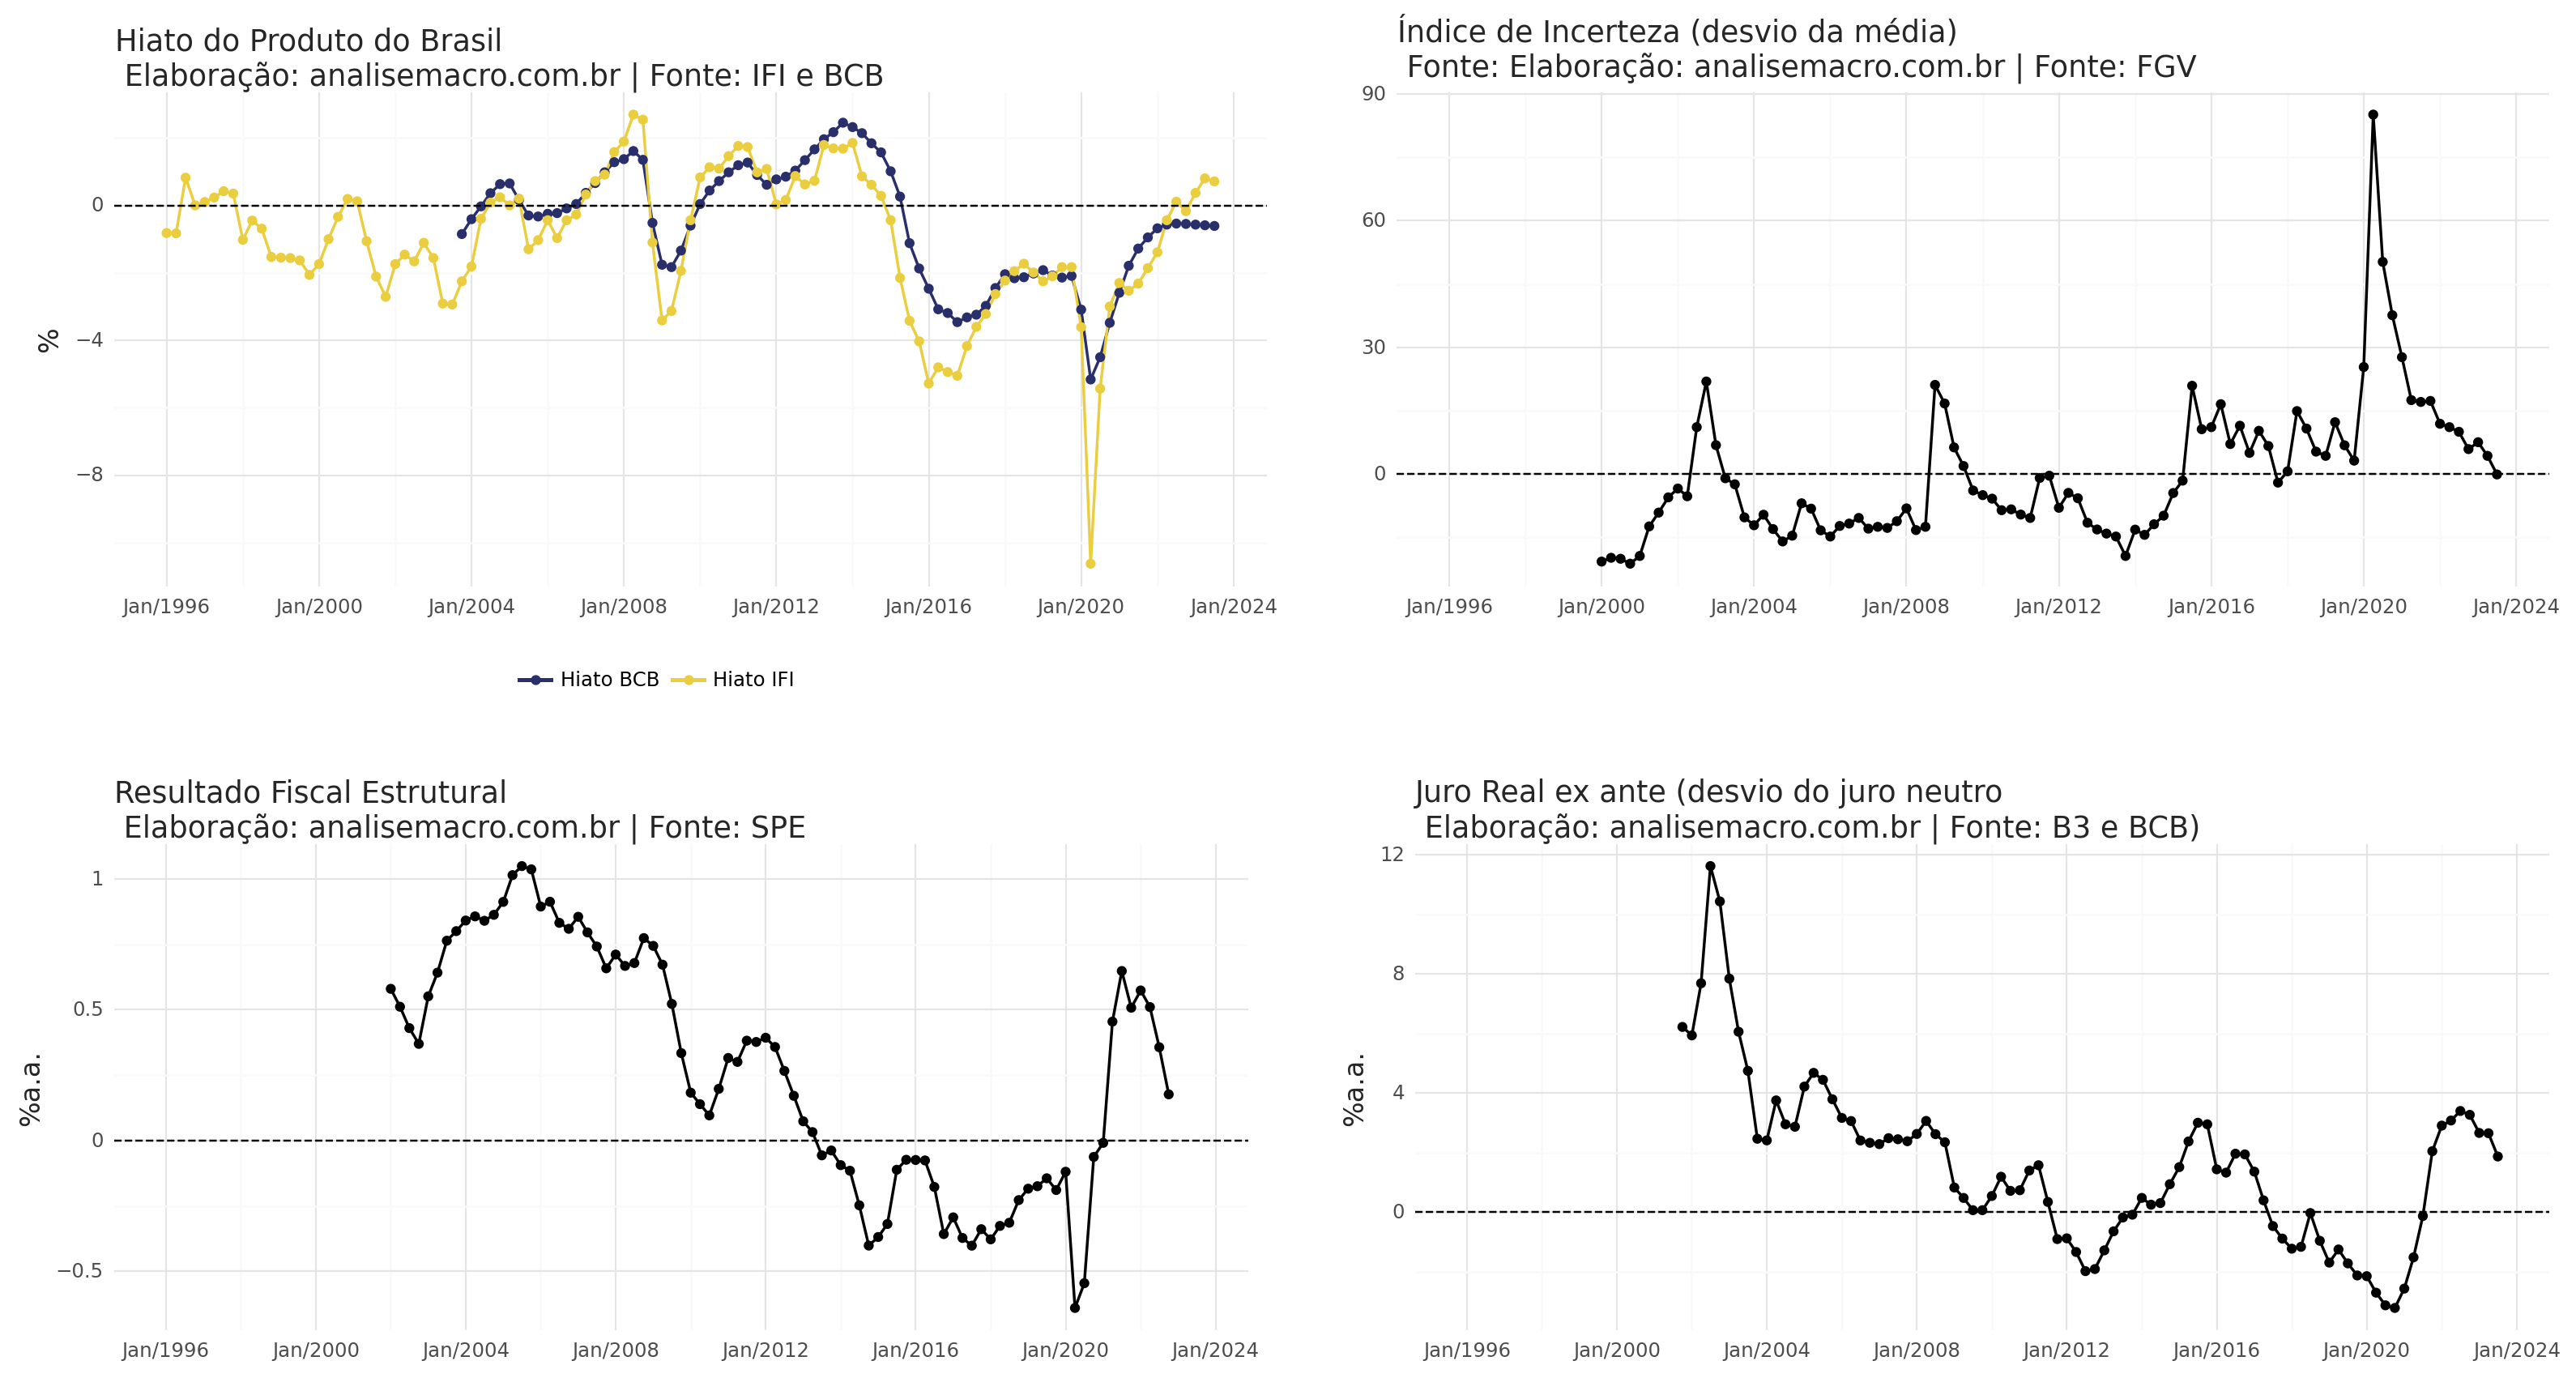

In [ ]:
(g1 | g2) / (g3 | g4)

# 4. Modelo Econométrico



## 4.1 Criação das defasagens

In [ ]:
# Calcula as defasagens
dados['hiato_bcb_lag1'] = dados['hiato_bcb'].shift(1)
dados['hiato_bcb_lag2'] = dados['hiato_bcb'].shift(2)
dados['hiato_ifi_lag1'] = dados['hiato_ifi'].shift(1)
dados['hiato_ifi_lag2'] = dados['hiato_ifi'].shift(2)
dados['sup_lag1'] = dados['sup'].shift(1)
dados['hiato_juros_lag1'] = dados['hiato_juros'].shift(1)
dados['hiato_juros_lag2'] = dados['hiato_juros'].shift(2)
dados['iie_diff_lag1'] = dados['iie_diff'].shift(1)
dados['iie_diff_lag2'] = dados['iie_diff'].shift(2)

## 4.2 Modelo Estático



### 4.2.1 Modelo com Hiato do BCB

In [ ]:
# Estimando o modelo
model_bcb = IVGMM.from_formula(
    'hiato_bcb ~ [hiato_bcb_lag1 + hiato_juros_lag1 + sup + iie_diff ~ hiato_bcb_lag2 + hiato_juros_lag2 + sup_lag1 + iie_diff_lag1]',
    data = dados.dropna()
    ).fit()

# Imprimindo o sumário do modelo
model_bcb.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-GMM Estimation Summary                           
==============================================================================
Dep. Variable:              hiato_bcb   R-squared:                      0.9633
Estimator:                     IV-GMM   Adj. R-squared:                 0.9612
No. Observations:                  75   F-statistic:                    2868.7
Date:                Fri, Jan 05 2024   P-value (F-stat)                0.0000
Time:                        17:16:22   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                                Parameter Estimates                                 
====================================================================================
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
hiato_bcb_lag1       0.8217     0.0534     15.383     0.0000      0.7170      0.9264
hiato_juros_lag1    -0.1845     0.0347    -5.3177     0.0000     -0.2526     -0.1165
sup                  0.5336     0.0919     5.8081     0.0000      0.3535      0.7136
iie_diff            -0.0193     0.0097    -2.0006     0.0454     -0.0383     -0.0004
====================================================================================

Endogenous: hiato_bcb_lag1, hiato_juros_lag1, sup, iie_diff
Instruments: hiato_bcb_lag2, hiato_juros_lag2, sup_lag1, iie_diff_lag1
GMM Covariance
Debiased: False
Robust (Heteroskedastic)
"""

#### 4.2.1.1 Análise dos Resíduos

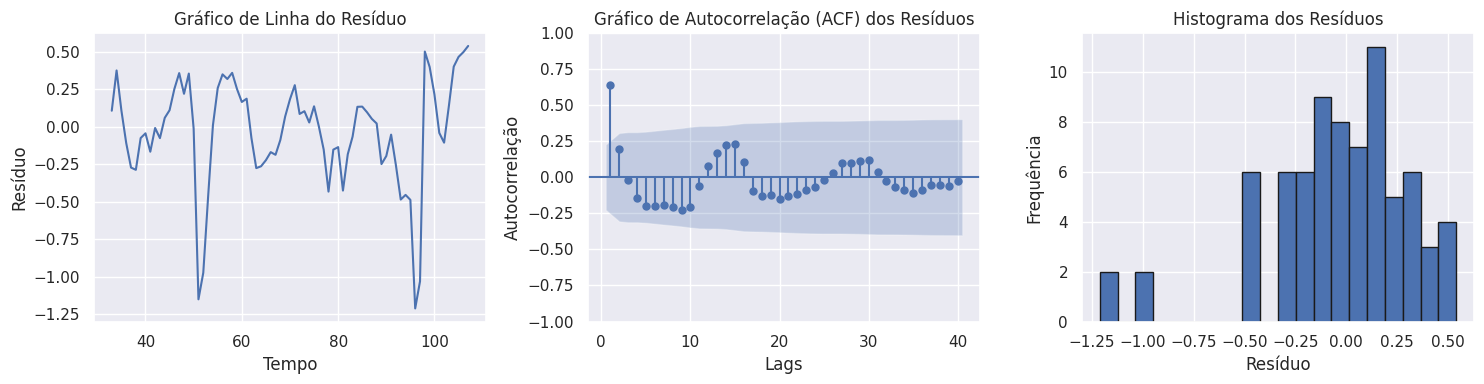

In [ ]:
# Cria uma figura com 1 linha e 3 colunas para os três gráficos
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Gráfico de Linha do Resíduo
axes[0].plot(model_bcb.resids)
axes[0].set_title('Gráfico de Linha do Resíduo')
axes[0].set_xlabel('Tempo')
axes[0].set_ylabel('Resíduo')

# Gráfico de Autocorrelação (ACF)
sm.graphics.tsa.plot_acf(model_bcb.resids, lags=40, ax=axes[1], zero = False)
axes[1].set_title('Gráfico de Autocorrelação (ACF) dos Resíduos')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação')

# Gráfico de Histograma
axes[2].hist(model_bcb.resids, bins=20, edgecolor='k')
axes[2].set_title('Histograma dos Resíduos')
axes[2].set_xlabel('Resíduo')
axes[2].set_ylabel('Frequência')

plt.tight_layout()  # Para garantir que os gráficos não se sobreponham
plt.show()

### 4.2.2 Modelo com Hiato da IFI

In [ ]:
# Estimando o modelo
model_ifi = IVGMM.from_formula(
    'hiato_ifi ~ [hiato_ifi_lag1 + hiato_juros_lag1 + sup + iie_diff ~ hiato_ifi_lag2 + hiato_juros_lag2 + sup_lag1 + iie_diff_lag1]',
    data = dados.drop(columns = ['hiato_bcb', 'hiato_bcb_lag1', 'hiato_bcb_lag2']).dropna()
    ).fit()

# Imprimindo o sumário do modelo
model_ifi.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-GMM Estimation Summary                           
==============================================================================
Dep. Variable:              hiato_ifi   R-squared:                      0.7927
Estimator:                     IV-GMM   Adj. R-squared:                 0.7822
No. Observations:                  83   F-statistic:                    337.58
Date:                Fri, Jan 05 2024   P-value (F-stat)                0.0000
Time:                        17:16:23   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                                Parameter Estimates                                 
====================================================================================
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
hiato_ifi_lag1       0.7576     0.1289     5.8760     0.0000      0.5049      1.0103
hiato_juros_lag1    -0.1218     0.0578    -2.1067     0.0351     -0.2352     -0.0085
sup                  0.4195     0.3491     1.2018     0.2295     -0.2647      1.1037
iie_diff            -0.0126     0.0361    -0.3488     0.7272     -0.0833      0.0581
====================================================================================

Endogenous: hiato_ifi_lag1, hiato_juros_lag1, sup, iie_diff
Instruments: hiato_ifi_lag2, hiato_juros_lag2, sup_lag1, iie_diff_lag1
GMM Covariance
Debiased: False
Robust (Heteroskedastic)
"""

#### 4.2.2.1 Análise dos Resíduos

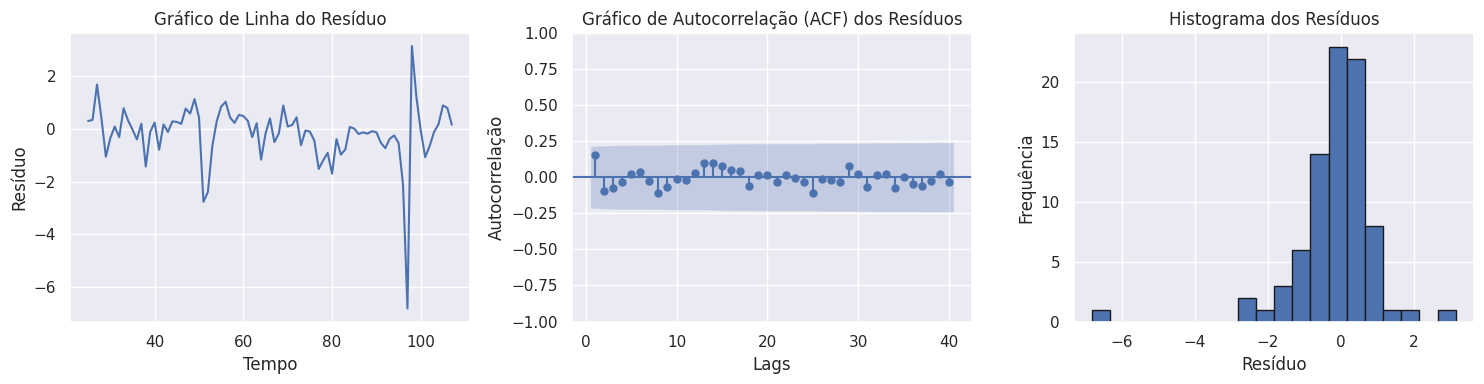

In [ ]:
# Cria uma figura com 1 linha e 3 colunas para os três gráficos
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Gráfico de Linha do Resíduo
axes[0].plot(model_ifi.resids)
axes[0].set_title('Gráfico de Linha do Resíduo')
axes[0].set_xlabel('Tempo')
axes[0].set_ylabel('Resíduo')

# Gráfico de Autocorrelação (ACF)
sm.graphics.tsa.plot_acf(model_ifi.resids, lags=40, ax=axes[1], zero = False)
axes[1].set_title('Gráfico de Autocorrelação (ACF) dos Resíduos')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação')

# Gráfico de Histograma
axes[2].hist(model_ifi.resids, bins=20, edgecolor='k')
axes[2].set_title('Histograma dos Resíduos')
axes[2].set_xlabel('Resíduo')
axes[2].set_ylabel('Frequência')

plt.tight_layout()  # Para garantir que os gráficos não se sobreponham
plt.show()

In [ ]:
# Compara os modelos
compare({"BCB": model_bcb, "IFI": model_ifi})

,BCB,IFI
Dep. Variable,hiato_bcb,hiato_ifi
Estimator,IV-GMM,IV-GMM
No. Observations,75,83
Cov. Est.,robust,robust
R-squared,0.9633,0.7927
Adj. R-squared,0.9612,0.7822
F-statistic,2868.7,337.58
P-value (F-stat),0.0000,0.0000
==================,===========,===========
hiato_bcb_lag1,0.8217,


## 4.3 Modelo Econométrico em Janelas Móveis

In [ ]:
# Dados a serem utilizados
dados_reg_ifi = dados.drop(columns = ['hiato_bcb', 'hiato_bcb_lag1', 'hiato_bcb_lag2']).dropna()

dados_reg_bcb = dados.dropna()

In [ ]:
def roll_is_curve(data, window_size=56, dependent_var='', independent_vars=[], instrumental_vars=[]):

    # Número de observações
    n_obs = len(data)

    # Lista para armazenar os resultados das regressões
    results = []

    # Loop sobre as subamostras
    for i in range(n_obs - window_size + 1):
        sub_sample = data[i:i+window_size]

        # Construir a fórmula para o modelo
        formula = f'{dependent_var} ~ [' + ' + '.join(independent_vars) + '~' + ' + '.join(instrumental_vars) + ']'

        # Estimar o modelo GMM para a subamostra atual
        model = IVGMM.from_formula(formula, data=sub_sample).fit()

        # Armazenar os resultados
        result = {
            'start_date': sub_sample['Date'].iloc[0],
            'end_date': sub_sample['Date'].iloc[-1]
        }

        for var in independent_vars:
            result[f'beta_{var}'] = model.params[var]
            result[f'ci_lower_{var}'] = model.conf_int().loc[var][0]
            result[f'ci_upper_{var}'] = model.conf_int().loc[var][1]

        results.append(result)

    # Converter os resultados para um DataFrame
    results_df = pd.DataFrame(results)

    # Retornar o DataFrame com os resultados
    return results_df

In [ ]:
# Chamar a função e armazenar os resultados
resultados_ifi = roll_is_curve(dados_reg_ifi,
                               window_size=56,
                               dependent_var='hiato_ifi',
                               independent_vars=['hiato_ifi_lag1', 'hiato_juros_lag1', 'iie_diff'],
                               instrumental_vars=['hiato_ifi_lag2', 'hiato_juros_lag2', 'iie_diff_lag1'])

# Chamar a função e armazenar os resultados
resultados_bcb = roll_is_curve(dados_reg_bcb,
                               window_size=56,
                               dependent_var='hiato_bcb',
                               independent_vars=['hiato_bcb_lag1', 'hiato_juros_lag1', 'iie_diff'],
                               instrumental_vars=['hiato_bcb_lag2', 'hiato_juros_lag2', 'iie_diff_lag1'])

,start_date,end_date,beta_hiato_bcb_lag1,ci_lower_hiato_bcb_lag1,ci_upper_hiato_bcb_lag1,beta_hiato_juros_lag1,ci_lower_hiato_juros_lag1,ci_upper_hiato_juros_lag1,beta_iie_diff,ci_lower_iie_diff,ci_upper_iie_diff
0,2004-04-01,2018-01-01,0.744155,0.689400,0.798910,-0.152211,-0.177864,-0.126557,-0.051521,-0.059575,-0.043467
1,2004-07-01,2018-04-01,0.749071,0.695507,0.802636,-0.151843,-0.177234,-0.126452,-0.050562,-0.058938,-0.042185
2,2004-10-01,2018-07-01,0.754493,0.702711,0.806275,-0.152676,-0.177678,-0.127673,-0.049785,-0.058114,-0.041457
3,2005-01-01,2018-10-01,0.757267,0.706629,0.807904,-0.151632,-0.176639,-0.126626,-0.049599,-0.058100,-0.041098
4,2005-04-01,2019-01-01,0.762751,0.712982,0.812521,-0.149081,-0.174178,-0.123985,-0.049330,-0.057996,-0.040664
5,2005-07-01,2019-04-01,0.767900,0.718566,0.817234,-0.146081,-0.172492,-0.119670,-0.048783,-0.057614,-0.039953
6,2005-10-01,2019-07-01,0.772574,0.723856,0.821292,-0.138753,-0.167685,-0.109821,-0.048846,-0.057774,-0.039918
7,2006-01-01,2019-10-01,0.781138,0.731254,0.831023,-0.129829,-0.161761,-0.097898,-0.048032,-0.057426,-0.038638
8,2006-04-01,2020-01-01,0.788421,0.730660,0.846181,-0.117141,-0.152725,-0.081557,-0.047294,-0.058799,-0.035789
9,2006-07-01,2020-04-01,0.790721,0.731270,0.850172,-0.122124,-0.166445,-0.077803,-0.043856,-0.055020,-0.032693


In [ ]:
# Cria o gráfico para a sensibilidade com hiato da ifi
gifi = pw.load_ggplot((ggplot(resultados_ifi)
    + geom_ribbon(aes(x='end_date', ymin='ci_lower_hiato_juros_lag1', ymax='ci_upper_hiato_juros_lag1'), fill='#282f6b', alpha=0.3)
    + geom_line(aes(x='end_date', y='beta_hiato_juros_lag1'), color='#282f6b', size=1.2)
    + geom_hline(yintercept = 0, color='black', linetype='dashed')
    + scale_x_datetime(date_breaks="1 years", date_labels="%Y")
    + labs(x='',
           y='',
           title = ' Sensibilidade da Política Monetária sobre a Atividade Econômica \n Produzido com o Hiato da IFI \n Fonte: analisemacro.com.br')
    + theme_minimal()
     ), figsize=(7, 4))

# Cria o gráfico para a sensibilidade com hiato do bcb
gbcb = pw.load_ggplot((ggplot(resultados_bcb)
    + geom_ribbon(aes(x='end_date', ymin='ci_lower_hiato_juros_lag1', ymax='ci_upper_hiato_juros_lag1'), fill='#282f6b', alpha=0.3)
    + geom_line(aes(x='end_date', y='beta_hiato_juros_lag1'), color='#282f6b', size=1.2)
    + geom_hline(yintercept = 0, color='black', linetype='dashed')
    + scale_x_datetime(date_breaks="1 years", date_labels="%Y")
    + labs(x='',
           y='',
           title = ' Produzido com o Hiato do BCB \n Fonte: analisemacro.com.br')
    + theme_minimal()
    ), figsize=(7, 4))

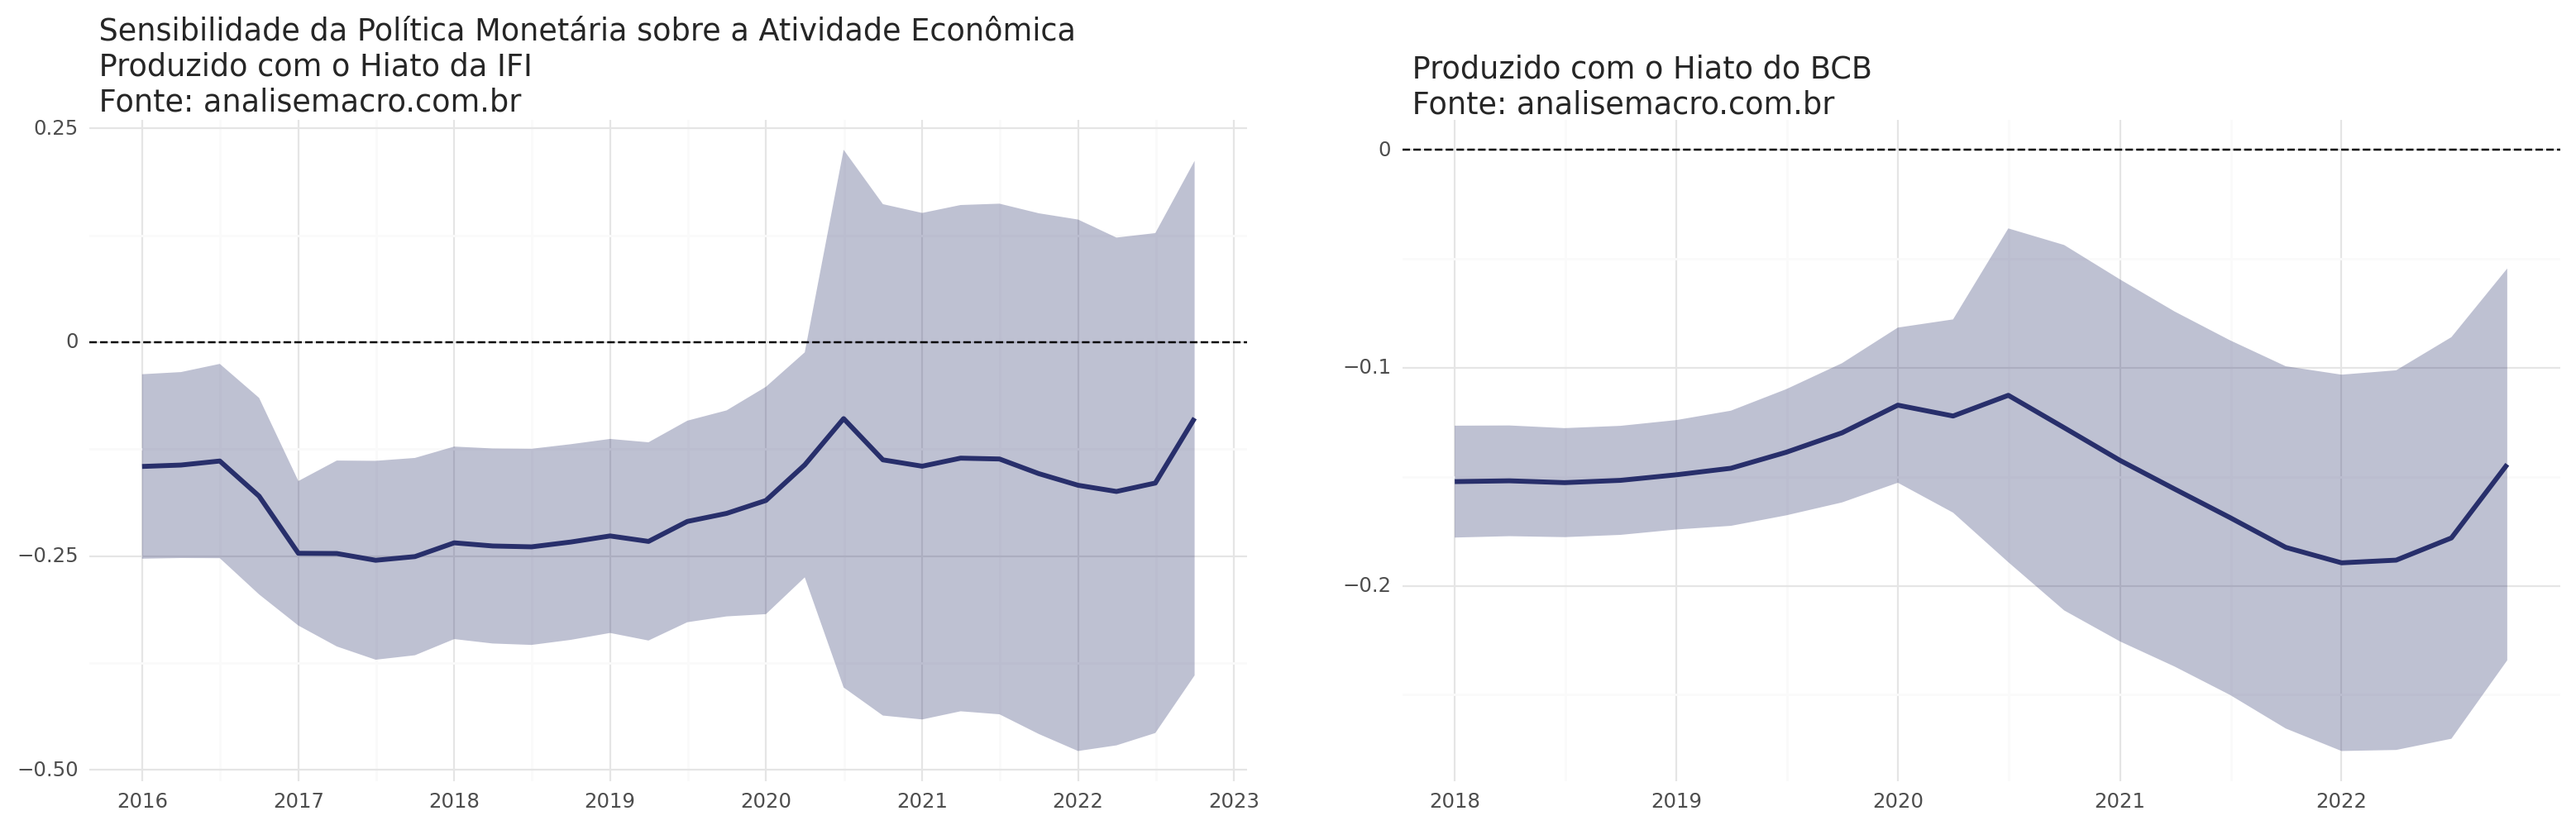

In [ ]:
(gifi|gbcb)